# Trial shh fit based on Briscoe work

Let's see if we can make this work ;).

This is not necessarily going to be very biological just yet; trying to get the functionality to work.

To get this to fully work, we'll probably need some kind of threshold function for gli2.

We will probably also need pax6 and irx3 repression thrown in.

In [1]:
import dinkum
from dinkum.vfg import Gene, Receptor, Ligand
from dinkum.vfn import Tissue
from dinkum import vfg, vfn

from dinkum.display import MultiTissuePanel, tc_record_activity
from dinkum.vfg2 import (Growth, Decay, LinearCombination, GeneTimecourse, LogisticActivator, run_lmfit,
                         LogisticRepressor, calc_response_1d, calc_response_2d, LogisticMultiRepressor)


import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from itertools import chain

initializing: dinkum v0.5.0
[0, 0, 0, 0, 0, 0, 0, 100, 0, 100, 0, 100, 0, 0, 100, 0, 100, 0, 100, 0]
start=1 stop=10


  0%|                                                  | 0/1000 [00:00<?, ?it/s]/Users/t/miniforge3/envs/py311/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████| 1000/1000 [00:12<00:00, 82.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [107.67569056  72.48537239 106.27574114  56.48985059]
fit values:
	nkx2_rate: fit=72.8664702609937 (was: 11)
	nkx2_midpoint: fit=78.95547944936817 (was: 50.0)
	olig2_rate: fit=64.36191787157517 (was: 11)
	olig2_midpoint: fit=71.917784602172 (was: 50.0)
start=1 stop=10


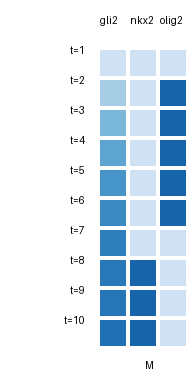

In [2]:
dinkum.reset()

m = Tissue(name='M')

# for now, just make this a straight up TF, instead of a receptor
gli2 = Gene(name='gli2')

nkx2 = Gene(name='nkx2')
olig2 = Gene(name='olig2')
ubiq = Gene(name='ubiq')

# for the moment, ignore other genes
#pax6 = Gene(name='pax6')
#irx3 = Gene(name='irx3')

# supply ubiquitous activator:
ubiq.is_present(where=m, start=1)

# have gli2 grow slowly over time
gli2.custom2(Growth(start_time=1, rate=0.25, initial_level=0, tissue=m))

# use a logistic activation function for nkx2, based solely on gli2 levels:
nkx2.custom2(LogisticActivator(activator_name='gli2'))

# use a ubiquitous activator 
olig2.custom2(LogisticRepressor(activator_name='ubiq', repressor_name='gli2'))

# our desired pattern of expression over time:
# at low gli2, nkx2 is off, and then turns on at high nkx2
nkx2_goal = [0]*7 + [100]*3
# at low gli2, olig2 is on, and then turns off.
olig2_goal = [0]*3 + [100]*3 + [0]*4

# make the "total goal"
total_goal = list(chain.from_iterable(zip(nkx2_goal, olig2_goal)))
print(total_goal)

# run fit:
run_lmfit(1, 10, total_goal, [nkx2, olig2], method='emcee')

# show results!
display_fn, conc_df, active_df = dinkum.run_and_display_df(start=1, stop=10,
                                                           gene_names=['gli2', 'nkx2', 'olig2'])
display_fn

## Show the computed response of nkx2 and olig2 to gli2

Plot the response rate with the fit parameters.

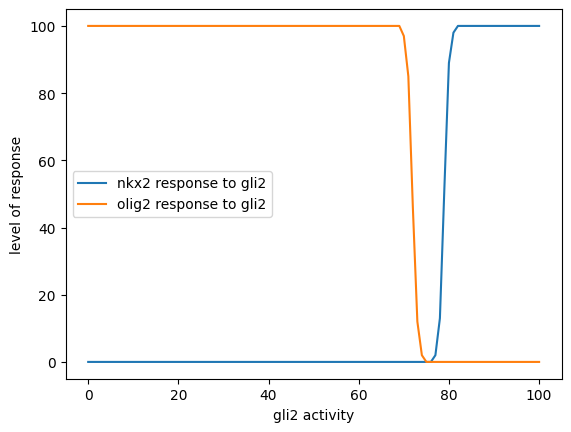

In [3]:
xvals, yvals_nkx2 = calc_response_1d(timepoint=2, target_gene_name='nkx2', variable_gene_name='gli2')
plt.plot(xvals, yvals_nkx2, label='nkx2 response to gli2')

xvals, yvals_olig2 = calc_response_1d(timepoint=2, target_gene_name='olig2', variable_gene_name='gli2',
                                     fixed_gene_states = {'ubiq': vfg.GeneStateInfo(100, True)})
plt.plot(xvals, yvals_olig2, label='olig2 response to gli2')
plt.xlabel('gli2 activity')
plt.ylabel('level of response')

plt.legend()